# Reduce a DFXM rocking scan measured at APS 6-ID-C

A theta rock or a theta-2theta scan, in the 2021 named layout or the 2025 indexed layout
(several frames per point). This is Part B of the school tutorial
(`rocking_curve_reconstruction_tutorial.ipynb`) on its own, plus a cell to pick the region of
interest from the frames. Every step has a check that can come back the other way; read each
summary before the map it belongs to.

**Steps:** set the paths in B1 · run **B0** and read the ROI off the picture · put it into `ROI`
and run everything from B1. With no `SCAN_DIR`, everything runs on a synthetic theta rock with a
known answer. For a theta-2theta scan (2theta logged moving with theta) the loader classifies
the scan as `strain` and every map comes out as a relative d-spacing change in microstrain.


### B0. Where is the grain? Pick the ROI

A 6-ID-C frame is 2560 x 2160 px, 22 MB as float32; a 101-point scan without a crop needs
~9 GB, so B1 refuses to load a real scan until `ROI` is set. This cell reads one frame from
every 10th point and shows their maximum minus their median, with row and column numbers on the
axes. Draw your box a little larger than the bright region and put it into `ROI` in B1 as
`(row0, row1, col0, col1)`. It also counts the frames against the motor table: the count must
be a whole number of images per point, and the file indices contiguous, or the folder is
incomplete.


In [1]:
import os, re
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import midas_dfxm as dx

SCAN_DIR    = None   # e.g. r"D:\raw_data\scans_raw\DFXM_S996"  (2025 layout: data_NNNNN.tif)
MOTOR_TABLE = None   # e.g. r"D:\raw_data\motor_files\<name>_motor_information_S996_0.07s.csv"
ROI_GUESS   = None   # optional (row0, row1, col0, col1) to draw on the picture

if SCAN_DIR and os.path.isdir(SCAN_DIR):
    names = sorted((f for f in os.listdir(SCAN_DIR) if re.match(r"^data_\d+\.tiff?$", f, re.I)),
                   key=lambda f: int(re.search(r"(\d+)", f).group(1)))
    if names:                                        # 2025 indexed layout
        idx = [int(re.search(r"(\d+)", f).group(1)) for f in names]
        contiguous = idx == list(range(idx[0], idx[0] + len(idx)))
        n_pts = len(next(iter(dx.read_motor_table(MOTOR_TABLE).values()))) if MOTOR_TABLE else None
        print(f"{len(names)} frames, indices {idx[0]}..{idx[-1]}, contiguous: {contiguous}")
        if n_pts:
            print(f"{n_pts} motor-table points -> {len(names) / n_pts:g} images per point")
            if len(names) % n_pts or not contiguous:
                print("STOP: frames are missing or this table belongs to another scan.")
        R = max(len(names) // n_pts, 1) if n_pts else 1
        picks = [names[p * R] for p in range(0, (len(names) // R), max((len(names) // R) // 10, 1))]
    else:                                            # 2021 named layout: any tif
        names = sorted(f for f in os.listdir(SCAN_DIR) if f.lower().endswith((".tif", ".tiff")))
        picks = names[::max(len(names) // 10, 1)]
    stack = np.stack([tifffile.imread(os.path.join(SCAN_DIR, f)).astype(np.float32) for f in picks])
    img = stack.max(0) - np.median(stack, 0)
    fig, ax = plt.subplots(figsize=(7, 6.2))
    im = ax.imshow(img, cmap="magma", vmin=0, vmax=np.percentile(img, 99.8))
    if ROI_GUESS:
        r0, r1, c0, c1 = ROI_GUESS
        ax.add_patch(plt.Rectangle((c0, r0), c1 - c0, r1 - r0, fill=False, color="cyan", lw=1.5))
    ax.set_title(f"max - median over {len(picks)} frames; read the ROI off the axes", fontsize=10)
    ax.set_xlabel("column"); ax.set_ylabel("row"); ax.grid(True, alpha=0.3)
    plt.colorbar(im, ax=ax, fraction=0.046); plt.show()
else:
    print("No SCAN_DIR: skip B0. B1 will run on a synthetic scan with a known answer.")


No SCAN_DIR: skip B0. B1 will run on a synthetic scan with a known answer.


## Part B — reduce a scan you measured (APS 6-ID-C)

This runs on **real detector frames**, with the package functions `load_6idc_scan`, `check_frame_order`, `reduce_rocking` and
`baseline_sensitivity` — tested against planted answers, not code that lives only in this
notebook.

**You need** the scan's frame folder and its motor table:

| acquisition | frames | motor table |
|---|---|---|
| 2021–2023 (e.g. NaMnO2) | `.../S006/*.tif`, angles also in the file names | `S006_motorInfo.csv`, one row per frame |
| 2025 onward | `.../scans_raw/DFXM_S190/data_00000.tif`, several repeats per point | `motor_files/<name>_motor_information_S190_<exposure>s.csv`, one row per point |

**No scan of your own yet?** Practice on the public NaMnO2 data (Plumb *et al.*, Mater. Charact.
**204**, 113174 (2023); Dryad [doi:10.25349/D9S03T](https://doi.org/10.25349/D9S03T)). In a
browser, download `Plumb_DFXM_Dec2021_data_S006.zip` (~220 MB) and
`Plumb_DFXM_Dec2021_motors.zip`, and unzip both. Use the table from the **December 2021** motors
archive: the deposit's July 2021 logs carry the same file names and the wrong angles for these
frames. The grain sits roughly in `ROI = (800, 1600, 900, 1700)`.

- **Two motor tables with the same name?** If you also have the July 2021 logs, the December
  `S006_motorInfo.csv` has one row per frame (41); the July one has 2050 rows and 2θ = 22.874.
  `load_6idc_scan` refuses the July table, and refuses to guess when it finds both.
- **Why the NaMnO2 file names look like a θ–2θ scan.** Two numbers in each name step together
  (one is twice the other plus a constant). That is a naming convention, not a measurement; the
  motor log shows 2θ fixed. Always classify a scan from its log.
- **Darks.** The practice deposit has none: leave `DARK = None`; the per-pixel baseline absorbs
  the dark level. At the beamline ask for a dark at the same exposure — it matters for
  intensities and the error model much more than for the tilt map.
- **Repeats (2025 layout).** Frames are read point-major (`order="point"`: every repeat of point
  1, then point 2, ...). Confirm the acquisition order with the beamline instead of
  switching `order` until B2 passes: repeat-major frames read point-major pass B2, and so can
  point-major frames read repeat-major when the first repeat is brighter and the number of
  points shares a factor with the number of repeats (51 points x 3 repeats, say). With 3 or more repeats,
  a first repeat more than 1 % brighter than the others is dropped automatically
  (`drop_first_repeat`); with 2 repeats nothing is dropped, so the repeat check still runs.

**Memory.** A full frame is 2560 × 2160 px, 22 MB as float32; 41 frames need ~0.9 GB. Set `ROI`
to crop as the frames load.

**No `SCAN_DIR` at all?** Part B then runs on a synthetic scan,
`dx.example_rocking_scan("broad")`, built to reproduce a failure met on real 6-ID-C data (every
pixel's curve 30 mdeg wide with sharp horns, and no tilt anywhere), so every cell below shows
output and the lesson works without a download.

Eight steps, each with a check that can come back the other way:
**B1** load and read the survey · **B2** is every frame paired with its own angle? ·
**B3** reduce: pedestal, centre, width, error bar · **B4** does the map deserve trust? Look at
the curves · **B5** a reduction that uses the whole curve · **B6** the frames at one motor
position · **B7** how much does the baseline choice matter? · **B8** what the map can and
cannot tell you.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import midas_dfxm as dx

# Part A's CFG block drives the simulation only. Part B reads everything from the scan's own
# motor table, and keeps detector rows and columns as recorded (no flips).

# ---- the only lines you change -----------------------------------------------------
SCAN_DIR    = SCAN_DIR if "SCAN_DIR" in dir() and SCAN_DIR else None   # set in B0, or here
MOTOR_TABLE = MOTOR_TABLE if "MOTOR_TABLE" in dir() and MOTOR_TABLE else None
ROI         = None   # (row0, row1, col0, col1) read off the B0 picture; required for a real scan
DARK        = None   # a dark frame, a folder of darks, or a number -- same exposure as the scan
GAIN        = None   # electrons per count if the detector record gives it; None = unknown
# -------------------------------------------------------------------------------------

HAVE_SCAN = bool(SCAN_DIR) and os.path.isdir(SCAN_DIR)
if HAVE_SCAN and ROI is None:
    raise SystemExit("set ROI from the B0 picture first: a full-frame scan needs ~9 GB")
if HAVE_SCAN:
    scan = dx.load_6idc_scan(SCAN_DIR, MOTOR_TABLE, roi=ROI, dark=DARK)
else:
    # No scan yet: a synthetic one, built to reproduce a real failure. Every pixel's curve is a
    # 30 mdeg box with sharp horns at both ends and NO tilt anywhere; only the horn heights
    # change across a line down the middle. The frames also carry a planted 2 px rms jitter
    # between repeats (B6). scan.meta["truth"] holds the planted answer.
    scan = dx.example_rocking_scan("broad", n_repeats=4, motion_px=2.0, seed=0)
    GAIN = scan.meta["truth"]["gain"]
    print("No SCAN_DIR set: using dx.example_rocking_scan('broad'), a synthetic scan with a known answer.\n")
print(scan.summary())


No SCAN_DIR set: using dx.example_rocking_scan('broad'), a synthetic scan with a known answer.

source      example_rocking_scan('broad')
frames      101 points x 64 x 64 px, 4 repeat(s) averaged per point
scan type   tilt (rocking coordinate: th)
2theta      16.6400 deg (median of the motor log)
moves       th: 7.3000 .. 7.4000 deg, step 1.000 mdeg
split-half  repeat parity


### B2. Is every frame paired with its own angle?

Do this before looking at any map. A stack whose frames are paired with the wrong angles still
produces a smooth, plausible map — no error, no warning. `check_frame_order` compares how alike
neighbouring frames are with the same score for random orderings of the same frames and, when
the scan has repeats, how closely two repeats of one point agree.

**CONSISTENT** is required before going on. **NOT CONFIRMED** means find out why — the file
order, the wrong motor table, repeats read in the wrong order — or the scan has no contrast to
test with.

**What CONSISTENT does not tell you.** It rules out a random or badly scrambled pairing, and
nothing more. A reversed sweep (every tilt changes sign), a table with the right number of rows
but the wrong step (every tilt scales), a constant angle offset, repeat-major frames read point-major, or any
other *smooth* wrong
order passes with the same score. `load_6idc_scan` guards the file side — natural sort,
contiguous frame numbers, row count, a file-name angle that must equal the logged one — but the
motor table itself you have to trust. A brighter first repeat can also let point-major
frames read repeat-major pass, when the number of points shares a factor with the number of
repeats; the loader's note on the first repeat is worth reading.

Look at the rocking curve too: one peak, inside the scanned range, not cut off at either end.


frame order CONSISTENT: adjacent-frame correlation 0.136 vs random orders median 0.021, p99 0.051 (p = 0.00498); repeat halves of one point differ by 0.0373x the random-pairing median (p = 0.00498) [205 px, 200 permutations, smallest possible p 0.00498]. This rules out a scrambled pairing, not a reversed sweep or a wrong step or offset in the motor table.


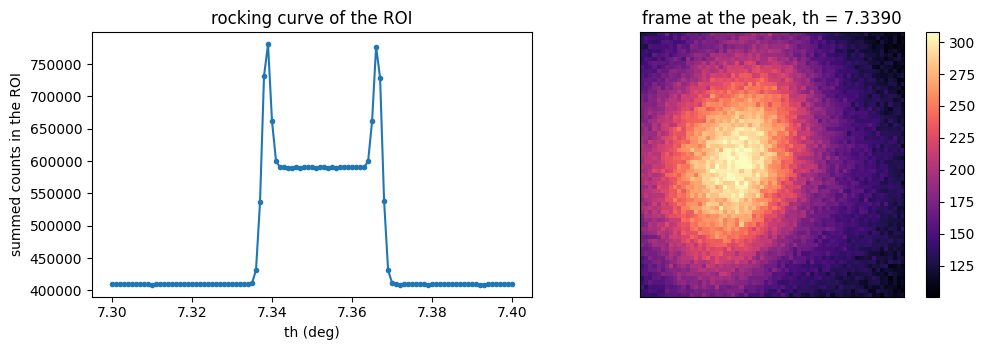

In [3]:
order_check = dx.check_frame_order(scan)
print(order_check)
x = scan.coordinate
curve = scan.frames.reshape(len(x), -1).sum(1)
k = int(np.argmax(curve))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(x, curve, "o-", ms=3)
ax[0].set_xlabel(f"{scan.axes[0]}{' / 2' if scan.scan_type == 'strain' else ''} (deg)")
ax[0].set_ylabel("summed counts in the ROI"); ax[0].set_title("rocking curve of the ROI")
im = ax[1].imshow(scan.frames[k], cmap="magma", vmax=np.percentile(scan.frames[k], 99.5))
ax[1].set_title(f"frame at the peak, {scan.axes[0]} = {x[k]:.4f}")
plt.colorbar(im, ax=ax[1], fraction=0.046); ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()


### B3. Reduce: pedestal, centre, width, error bar

On these detectors the **pedestal** (dark level plus diffuse background) carries most of the
recorded counts — the summary prints the share. A first moment taken on raw frames is pulled
toward the middle of the scan, so tilts come out many times too small while the map still looks
smooth. `reduce_rocking` therefore works pixel by pixel:

1. find the pixel's peak and measure its baseline on the frames **outside** the peak;
2. subtract it and take the centre (first moment) **inside** the peak;
3. take the width from the half-maximum crossings (instrument included);
4. repeat the centre on two independent halves of the data — two sets of repeats if the scan
   has them, otherwise even and odd frames — for an **error bar** that needs no noise model.

A pixel is **lit** when its integrated intensity is at least 10× its own noise, measured off
the peak; a few background pixels (about 0.1–0.2 % of pure noise) still pass by chance.
**Truncated** means the pixel's peak *window* (±2 widths) reaches an end of the scan: a peak cut
off by the scan range, but also a very wide or double-peaked pixel. Its centre may be biased, and
the summary leaves it out.

The map is a tilt in mdeg — or, for a θ–2θ scan, a relative d-spacing change in microstrain —
**relative to the median of the lit pixels**, in detector rows and columns.

This is the standard reduction, and it assumes **one peak per pixel**. B4 checks whether that
holds. Read the `shape` line of the summary before reading the map.


tilt map: 3812 lit px (93.1% of the ROI); 81 of them have their peak window at a scan edge (centre may be biased; left out below)
value       median 0 mdeg, IQR [-9.14, 10.6], p2-p98 [-11.5, 12.1] (relative to the reference; first moment in the peak window)
reference   1.46622 deg (median centre, lit pixels)
shape       3.8% of lit pixels are single-peaked (>= 45 % of the signal inside the half-max run, one feature above half max); for the other 96.2% the centre summarises a distribution of tilts, not one tilt
width       median 3.16 mdeg (contiguous half-max, instrument included); median 3 points above half max
error bar   0.192 mdeg per pixel (repeat parity split-half; one robust value over lit pixels, while the sigma map is a local 5x5 estimate)
repeats     frames at one position: variance spread p10-p90 = 0.77-1.38 x the lit-pixel median (photon noise alone gives a spread near 1; a wide spread is flux or motion between frames); 1.47 x photon noise at the given gain
repeats     betw

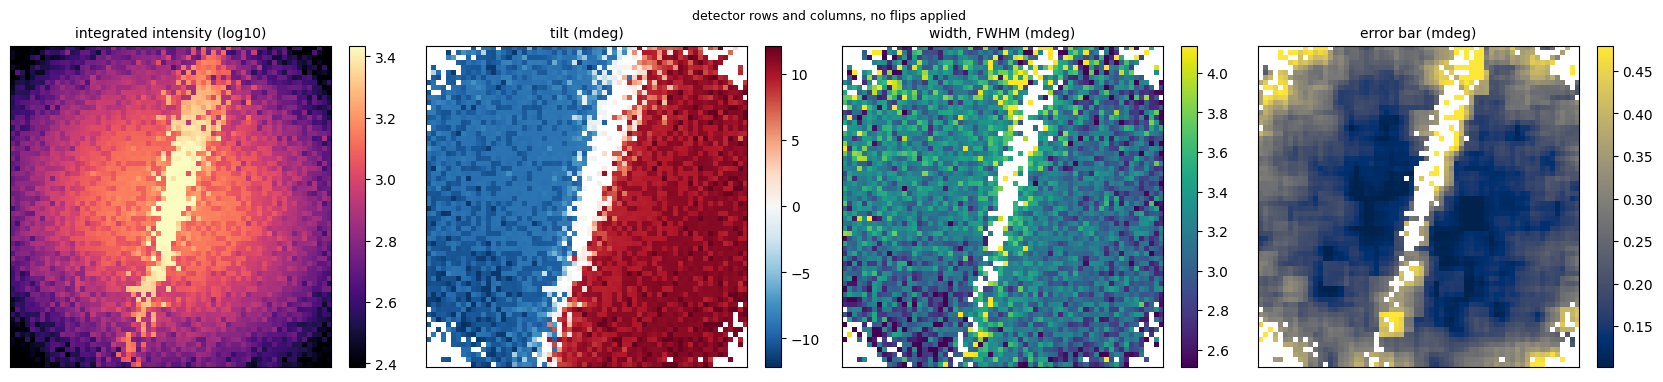

In [4]:
maps = dx.reduce_rocking(scan, gain=GAIN)
print(maps.summary())
show = maps.lit & ~maps.truncated
first = (lambda a: a if a is None or a.ndim == 2 else a[..., 0])
panels = [(np.log10(np.clip(maps.intensity, 1, None)), "integrated intensity (log10)", "magma", False),
          (np.where(show, first(maps.value), np.nan), f"{maps.scan_type} ({maps.unit})", "RdBu_r", True)]
if maps.fwhm_mdeg is not None:
    panels.append((np.where(show, maps.fwhm_mdeg, np.nan), "width, FWHM (mdeg)", "viridis", False))
if maps.sigma is not None:
    panels.append((np.where(show, first(maps.sigma), np.nan), f"error bar ({maps.unit})", "cividis", False))
fig, ax = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 3.8))
for a, (img, title, cmap, symmetric) in zip(ax, panels):
    if symmetric:
        lim = np.nanpercentile(np.abs(img), 98)
        im = a.imshow(img, cmap=cmap, vmin=-lim, vmax=lim)
    else:
        im = a.imshow(img, cmap=cmap, vmin=np.nanpercentile(img, 2), vmax=np.nanpercentile(img, 98))
    a.set_title(title, fontsize=10); a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.046)
plt.suptitle("detector rows and columns, no flips applied", fontsize=9)
plt.tight_layout(); plt.show()


### B4. Does the map deserve trust? Look at the curves

The summary's `shape` line says what fraction of lit pixels are **single-peaked**: at least 45 %
of the signal inside the contiguous run above half maximum, and only one such run. B3 assumes one
peak per pixel. Where that fails, its centre follows whichever feature is tallest and jumps where
that changes, and nothing in the map itself shows it. The raw curves do.

Below: the curve of the brightest lit pixel, and the pair of lit pixels 20 px apart on one row
whose B3 centres differ most, with those centres marked. On the example scan the pair straddles
the line where the taller horn switches: the two curves are nearly the same while the centres
differ by ~18 mdeg. That is what a reduction artifact looks like from the raw data. On a scan of
one-peak pixels the two curves differ as much as their centres do.


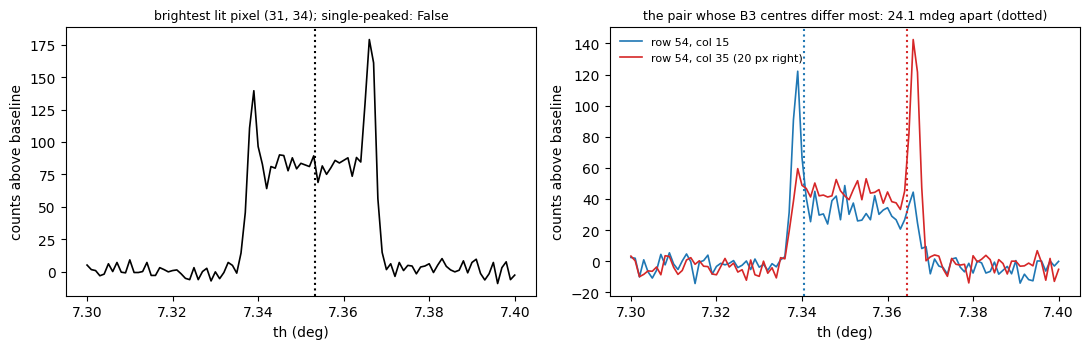

96% of lit pixels are not single-peaked: the B3 map cannot be read as a tilt map where they sit. Continue with B5.


In [5]:
show = maps.lit & ~maps.truncated
x = scan.coordinate
order = np.argsort(x)
frac_not_single = 1.0 - float(maps.single_peaked[maps.lit].mean())

def curve(r, c):
    return scan.frames[order, r, c] - maps.baseline[r, c]

rb, cb = np.unravel_index(np.argmax(np.where(show, maps.intensity, -np.inf)), maps.intensity.shape)
v = np.where(show, maps.value, np.nan)
v = v if v.ndim == 2 else v[..., 0]
d = np.abs(v[:, 20:] - v[:, :-20])
rp, cp = np.unravel_index(np.nanargmax(d), d.shape)
pair = [(rp, cp, f"row {rp}, col {cp}"), (rp, cp + 20, f"row {rp}, col {cp + 20} (20 px right)")]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(x[order], curve(rb, cb), color="k", lw=1.2)
ax[0].axvline(maps.centre_deg[rb, cb], color="k", ls=":")
ax[0].set_title(f"brightest lit pixel ({rb}, {cb}); single-peaked: {bool(maps.single_peaked[rb, cb])}", fontsize=9)
for (r, c, lab), col in zip(pair, ("C0", "C3")):
    ax[1].plot(x[order], curve(r, c), color=col, lw=1.2, label=lab)
    ax[1].axvline(maps.centre_deg[r, c], color=col, ls=":")
ax[1].set_title(f"the pair whose B3 centres differ most: {d[rp, cp]:.1f} {maps.unit} apart (dotted)", fontsize=9)
ax[1].legend(fontsize=8, frameon=False)
for a in ax:
    a.set_xlabel(f"{scan.axes[0]} (deg)"); a.set_ylabel("counts above baseline")
plt.tight_layout(); plt.show()
print(f"{frac_not_single:.0%} of lit pixels are not single-peaked: "
      + ("the B3 map cannot be read as a tilt map where they sit. Continue with B5."
         if frac_not_single > 0.2 else "the B3 map is a tilt map; B5 is a cross-check."))


### B5. A reduction that uses the whole curve

`window="fixed"` assumes nothing about the shape: one signal window for every pixel (where the
ROI-summed curve is above 1 % of its maximum, or `signal_range=(lo, hi)` in degrees), a straight
line through the frames outside it as the baseline, and the **median** of the pixel's curve as
the centre, the angle that splits its intensity in half. It cannot jump when a different feature
becomes the tallest. The width is the 10 % to 90 % span, and `centre_shift` is the centre of mass
minus the median: two defensible centres, and their disagreement is the size of the "which centre"
systematic, which no error bar contains.

What it does not do: a curve that is a distribution of tilts still has no single tilt. On the
example scan the median removes the ~18 mdeg jump and leaves a ~4 mdeg ramp across the same
line, because intensity moves from one horn to the other. That ramp is curve *shape*, not tilt,
and the `centre_shift` map is where to look for it. A real tilt step moves both centres by the
same amount (`dx.example_rocking_scan("step")` plants one, if you want to see that).


tilt map: 4096 lit px (100.0% of the ROI); 4 of them have their signal still above noise at the ends of the signal window (centre may be biased; left out below)
value       median 0 mdeg, IQR [-2.71, 2.88], p2-p98 [-3.91, 4.26] (relative to the reference; median of each pixel's curve)
reference   1.46814 deg (median centre, lit pixels)
shape       5.7% of lit pixels are single-peaked (>= 45 % of the signal inside the half-max run, one feature above half max); for the other 94.3% the centre summarises a distribution of tilts, not one tilt
centre def. centre of mass differs from the median by 0.616 mdeg (median), 1.07 (p90): the size of the 'which centre' systematic
width       10-90 % span of the whole curve, median 26.1 mdeg -- use this one: the curve may not be single-peaked (see shape). The tallest local feature alone is 3.22 mdeg wide (contiguous half-max, median 3 points above its own half max) and is NOT the curve's width unless a pixel is single-peaked.
error bar   0.465 mdeg per

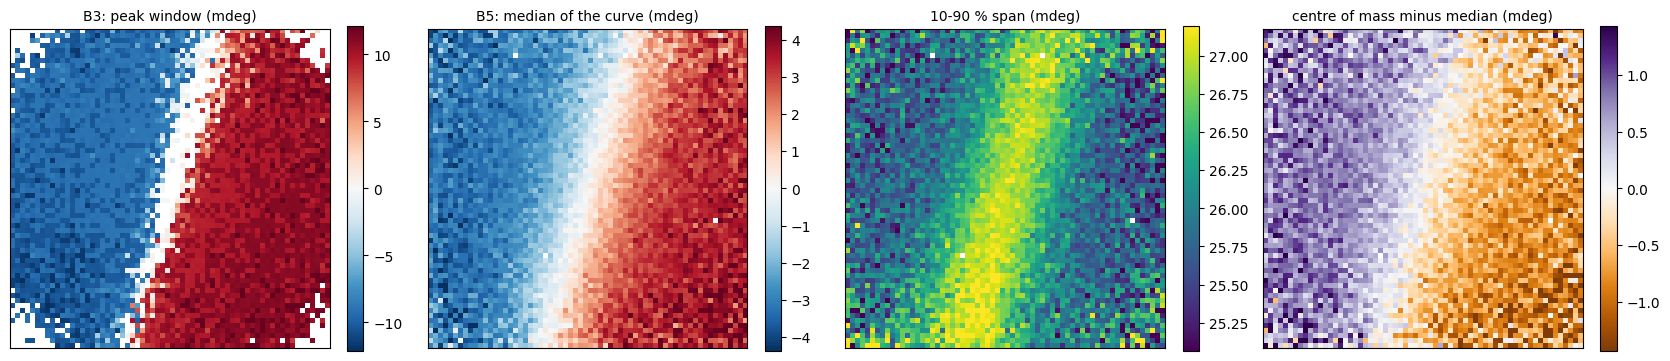

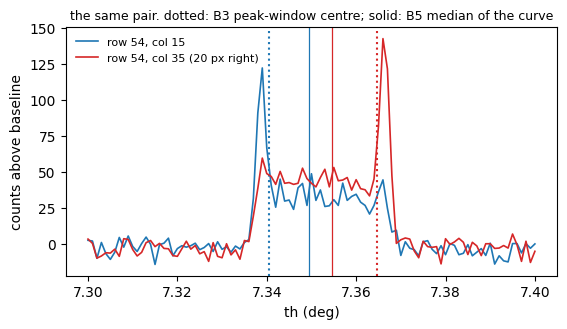

Using window='fixed' from here on.


In [6]:
fixed = dx.reduce_rocking(scan, window="fixed", gain=GAIN)
print(fixed.summary())
showf = fixed.lit & ~fixed.truncated
first = (lambda a: a if a is None or a.ndim == 2 else a[..., 0])
panels = [(np.where(show, first(maps.value), np.nan), f"B3: peak window ({maps.unit})", "RdBu_r", True),
          (np.where(showf, first(fixed.value), np.nan), f"B5: median of the curve ({fixed.unit})", "RdBu_r", True)]
if fixed.span_mdeg is not None:
    panels += [(np.where(showf, fixed.span_mdeg, np.nan), "10-90 % span (mdeg)", "viridis", False),
               (np.where(showf, first(fixed.centre_shift), np.nan), f"centre of mass minus median ({fixed.unit})", "PuOr", True)]
fig, ax = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 3.8))
for a, (img, title, cmap, symmetric) in zip(ax, panels):
    if symmetric:
        lim = np.nanpercentile(np.abs(img), 98)
        im = a.imshow(img, cmap=cmap, vmin=-lim, vmax=lim)
    else:
        im = a.imshow(img, cmap=cmap, vmin=np.nanpercentile(img, 2), vmax=np.nanpercentile(img, 98))
    a.set_title(title, fontsize=10); a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(5.8, 3.4))
for (r, c, lab), col in zip(pair, ("C0", "C3")):
    ax.plot(x[order], curve(r, c), color=col, lw=1.2, label=lab)
    ax.axvline(maps.centre_deg[r, c], color=col, ls=":")
    ax.axvline(fixed.centre_deg[r, c], color=col, ls="-", lw=0.9)
ax.set_xlabel(f"{scan.axes[0]} (deg)"); ax.set_ylabel("counts above baseline"); ax.legend(fontsize=8, frameon=False)
ax.set_title("the same pair. dotted: B3 peak-window centre; solid: B5 median of the curve", fontsize=9)
plt.tight_layout(); plt.show()
WINDOW = "fixed" if frac_not_single > 0.2 else "peak"
best = fixed if WINDOW == "fixed" else maps
print(f"Using window={WINDOW!r} from here on.")


### B6. The frames at one motor position

With repeats, the error bar comes from two halves of the repeats. It is often read as photon
noise. It is not: it includes everything that changes between frames taken at the same
position, flux, beam or sample motion. On a 6-ID-C scan the intensity pattern moved by a few
pixels between the 10 frames at one position, several times the photon noise, and the first
frame after each motor move carried a small detector offset (the loader's note on the first
repeat says how large). `repeat_excess` maps where the frames at one position disagree beyond
photon noise: the slope of the squared half-difference against the recorded level, per
7×7-pixel box, relative to the median over lit pixels. Photon noise alone gives a flat map
(p10 to p90 within about 0.6 to 1.4); motion shows up where the image has gradients. With a
known `GAIN` the summary also gives the absolute factor over photon noise (1.0 = photon noise only).
`repeat_shift_px` is gain-free and more direct: per frame, the apparent shift between the two
repeat halves at two scales, the **envelope** (the centroid of the baseline-subtracted signal)
and the **fine detail** (a least-squares fit of the half-difference to the image gradients, with
flux and angle terms so those do not leak in). Photon noise gives hundredths of a pixel on both.
On the 6-ID-C scan the envelope moved by a few pixels while the fine detail stayed within a
fraction of a pixel: the illumination moved over a still image. A rigid shift moves both.

What to do about it: nothing automatic. Averaging blurs whatever moves; registering the frames
first needs an estimator that cannot lock onto the detector's fixed pattern (a phase correlation
on raw frames does, and reads zero), and it is wrong if the illumination moves rather than the
image. Keep the repeat-parity error bar, which includes the effect, and say so when quoting widths.


repeat excess p10-p90: 0.77-1.36 x the lit-pixel median; 1.47 x photon noise at gain 1.0
between the repeat halves: envelope shifts 0.77 px rows / 0.99 px cols, fine detail 0.08 / 0.13 px (rms over 32 frames with signal)


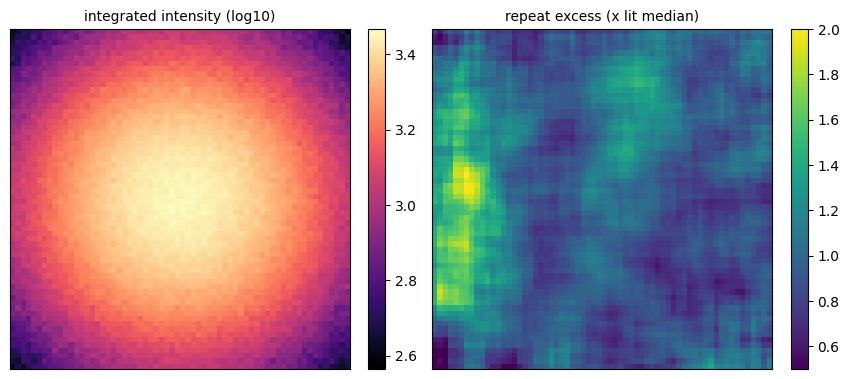

In [7]:
if best.repeat_excess is None:
    print("This scan has no repeat halves (one frame per point): no repeat-excess map. "
          "The error bar comes from even and odd frames and carries sampling error instead.")
else:
    lo, hi, absx = best.repeat_excess_spread
    print(f"repeat excess p10-p90: {lo:.2f}-{hi:.2f} x the lit-pixel median"
          + (f"; {absx:.2f} x photon noise at gain {GAIN}" if absx is not None
             else " (set GAIN for the absolute factor)"))
    ey, ex, fy, fx, nfr = best.repeat_shift_rms
    print(f"between the repeat halves: envelope shifts {ey:.2f} px rows / {ex:.2f} px cols, "
          f"fine detail {fy:.2f} / {fx:.2f} px (rms over {nfr} frames with signal)")
    fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.8))
    im = ax[0].imshow(np.log10(np.clip(best.intensity, 1, None)), cmap="magma")
    ax[0].set_title("integrated intensity (log10)", fontsize=10); plt.colorbar(im, ax=ax[0], fraction=0.046)
    im = ax[1].imshow(best.repeat_excess, cmap="viridis", vmin=0.5, vmax=max(2.0, hi))
    ax[1].set_title("repeat excess (x lit median)", fontsize=10); plt.colorbar(im, ax=ax[1], fraction=0.046)
    for a in ax:
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()


### B7. How much does the map depend on the baseline choice?

The baseline is a choice, and defensible choices differ. `baseline_sensitivity` redoes the map
with each alternative (for `window="fixed"`: the signal window 3 frames wider and narrower,
and two percentile baselines) and compares them on 8×8-pixel blocks, where noise averages out. **Block
RMS** is how far the map moves: quote it beside the error bar, not the variant that looks best.
A **block slope** far from 1 means the choice rescales every tilt. The per-pixel spread also
contains noise, so it is only an upper bound on the systematic.


In [8]:
for row in dx.baseline_sensitivity(scan, window=WINDOW):
    print(f"{str(row['variant']):58s} block RMS {row['block_rms']:6.3f} {row['unit']}, "
          f"block slope {row['block_slope']:.3f}, per-pixel spread {row['pixel_spread']:.2f} "
          f"({row['n_blocks']} blocks)")


{'signal_range': (7.329999999999999, 7.375000000000001)}   block RMS  0.017 mdeg, block slope 1.000, per-pixel spread 0.09 (60 blocks)
{'signal_range': (7.336000000000001, 7.368999999999999)}   block RMS  0.036 mdeg, block slope 0.989, per-pixel spread 0.12 (60 blocks)
{'baseline': 'percentile', 'baseline_percentile': 25.0}    block RMS  0.123 mdeg, block slope 0.958, per-pixel spread 0.13 (60 blocks)
{'baseline': 'percentile', 'baseline_percentile': 50.0}    block RMS  0.290 mdeg, block slope 1.098, per-pixel spread 0.28 (60 blocks)


### B8. What this map can and cannot tell you

- **Relative, not absolute.** Tilts are measured from the median of the lit pixels. One scan
  gives no absolute orientation and no absolute strain zero.
- **One component.** A θ rock senses tilt about the rocking axis only; tilt about the other
  axis is nearly invisible (§1). A full orientation needs a second, orthogonal rock (§5–6).
- **One reflection gives Δd/d, not elastic strain.** In a solid solution a change of
  composition moves d just as strain does; the strain *tensor* needs several non-coplanar
  reflections.
- **The error bar is the scatter between two halves of the data, for these settings.** It
  leaves out the baseline choice (B4) and anything the two halves share: angle errors at each
  point, flux changes between points (6-ID-C logs no flux monitor), drift, vibration. It also
  depends on the window. From repeats it includes everything that changes between frames at one
  position (B6), which can be several times the photon noise; from even and odd frames it also
  carries sampling error.
- **Coarse sampling.** With only 2–3 points above half maximum, widths are quantized by the
  step — stripes in the width map follow where each peak falls on the angle grid — and the
  centre is less certain than a photon-only error bar says.
- **A background that rises and falls with the rocking curve** (a halo around the grain, or
  weak diffraction below the lit cut) survives the per-pixel baseline and pulls tilts toward
  zero, by roughly one to two times its height as a fraction of the peak (planted scans). It is
  not in the error bar.
- **A centre is one number for a whole curve.** Where a pixel's curve is not one peak (B4),
  the centre says how that pixel's intensity is placed in angle, not what its tilt is; two
  defensible centres then disagree (B5, `centre_shift`), and a peak-window centre can jump
  where a different feature becomes the tallest. Separating the orientations inside one
  pixel needs many more points across each feature, and sometimes another scan.
- **The width includes the instrument.** Deconvolve a near-perfect crystal's width (§6) before
  calling it mosaic spread.
- **Lengths need the optics record.** µm per pixel is not in the motor table; take it from the
  objective's magnification record, not from a constant in someone's script.
- **Image orientation.** The maps are in detector rows and columns; relating them to the
  sample needs a fiducial (§1b, §7).


In [9]:
if HAVE_SCAN:
    out = "my_rocking_maps.npz"
    best.save(out)
    print("saved", os.path.abspath(out), f"-- every map from window={WINDOW!r}, the masks, and the settings used")
else:
    print("synthetic example: nothing saved")


synthetic example: nothing saved
